In [1]:
import pandas as pd
from math import cos, radians, sqrt
from sklearn.neighbors import BallTree
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, Point
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
import warnings
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from yellowbrick.cluster import KElbowVisualizer
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import binomtest
from tqdm import tqdm
from scipy.stats import chi2_contingency
from scipy.stats import norm
from sklearn.metrics.pairwise import haversine_distances

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
warnings.filterwarnings('ignore')

In [3]:
raw = "C:\\Users\\Taavi\\Desktop\\BPhil\\Raw data\\"
clean = "C:\\Users\\Taavi\\Desktop\\BPhil\\Clean data\\"

In [4]:
demos = pd.read_csv(clean + 'clean_demos.csv')
demos = demos.loc[demos['status'] == 'Completed']

In [5]:
parcels = pd.read_csv(clean + 'blight.csv')

In [2]:
# fig = px.scatter_mapbox(demos, lat = 'lat', lon = 'lng', zoom = 10)
# fig.update_layout(mapbox_style = 'open-street-map')
# fig.show()

In [6]:
merged = parcels.merge(right = demos.assign(demo = 1)[['parcelID', 'demo']], on = 'parcelID', how = 'left').fillna(0)

In [8]:
merged['blight'] = np.where(merged['demo'] == 1, 'Demo', merged['blight'])

In [1]:
# fig = px.scatter_mapbox(merged, lat = 'lat', lon = 'lng', zoom = 10, color = 'blight')
# fig.update_layout(mapbox_style = 'carto-positron')
# fig.show()

### Population average parcel-based demolition exposure

I want to measure exposure to demolitions for each parcel in the same way I measure exposure to blight. I guess I'm doing this across the static timeframe...?

Yes I'll do this measurement across the static timeframe to be able to identify parcels "untouched" by demos across the timeframe. "Untouched" meaning "experiencing less exposure to demos than the population average." I'll test for that with a z-score.

Turns out there aren't any parcels with significantly less exposure than the population average, because the average is low enough and the std dev is high enough. If anything there are just parcels with significantly more exposure. I can still use this. I can distinguish between those with significant exposure and those with average exposure, and suddenly I'll have two samples. Then I can compare blight levels across the samples, and more.

Yikes - our high-exposure sample is only 3.7% of the dataset.

Wow - grouping by blight, we can see that 35.6% of cluster 5 is highly exposed to demos and 6.2% of cluster 1 is highly exposed. After cluster 6 (and ignoring the inflated crime reporting in the Central Business District), these are the two worst-off clusters. I'm sure I know what the result will be, but let's quickly test for the significance of these percentages.

Interesting - every cluster significantly deviates from the population mean. Clusters 1 and 5 deviate above the mean, the rest are all below. Where there is high exposure to demolitions, it is in clusters 1 and 5. Notably, it is NOT in cluster 6.

In [9]:
demos['year'] = pd.to_datetime(demos['date']).dt.year
years = range(demos['year'].min(), demos['year'].max() + 1)

In [10]:
parcels = parcels.merge(pd.DataFrame({'date': years}), how = 'cross').sort_values(by = 'date').reset_index(drop = True)
#parcels['date'] = pd.to_datetime(parcels['date']).dt.year
parcels = parcels.rename(columns = {'date': 'year'})
years = range(demos['year'].min(), demos['year'].max() + 1)

In [23]:
full = pd.DataFrame()

earthRadius = 6_378_137 # meters

distances = np.arange(50, 800, 50)
distances_radians = distances / earthRadius
weights = [(i + 1) / len(distances) for i, r in enumerate(distances)][::-1]

for year in tqdm(years):
    parcels_sub = parcels.loc[parcels['year'] == year].reset_index(drop = True)
    values_sub = demos.loc[demos['year'] == year].reset_index(drop = True)

    parcels_coords = np.radians(parcels_sub[['lat', 'lng']].to_numpy())
    values_coords = np.radians(values_sub[['lat', 'lng']].to_numpy())

    value_tree = BallTree(values_coords, metric = 'haversine')
    
    # count demos in each distance bin
    for d_m, d_r in zip(distances, distances_radians):
        indices_within_radius = value_tree.query_radius(parcels_coords, r = d_r)
        counts = [len(idxs) for idxs in indices_within_radius]
        parcels_sub[f'demos_count_{d_m}'] = counts

        sums = [values_sub.loc[idxs, 'value'].sum() for idxs in indices_within_radius]
        parcels_sub[f'demos_sum_{d_m}'] = sums
        

    parcels_sub = parcels_sub.fillna(0)

    for i, r in enumerate(distances[::-1]):
        if r != distances[0]:
            parcels_sub[f'demos_count_{r}'] -= parcels_sub[f'demos_count_{distances[::-1][i + 1]}']
            parcels_sub[f'demos_sum_{r}'] -= parcels_sub[f'demos_sum_{distances[::-1][i + 1]}']

    parcels_sub['demos_count_decayed'] = (parcels_sub[[f'demos_count_{r}' for r in distances]] * weights).sum(axis = 1)
    parcels_sub['demos_sum_decayed'] = (parcels_sub[[f'demos_sum_{r}' for r in distances]] * weights).sum(axis = 1)

    # q1 = parcels_sub['demos_count_decayed'].quantile(0.25)
    # q3 = parcels_sub['demos_count_decayed'].quantile(0.75)
    # iqr = q3 - q1
    # lb = q1 - (1.5 * iqr)
    # ub = q3 + (1.5 * iqr)

    # parcels_sub['low_exposure'] = np.where(parcels_sub['demos_count_decayed'] < lb, 1, 0)
    # parcels_sub['high_exposure'] = np.where(parcels_sub['demos_count_decayed'] > ub, 1, 0)

    top_decile_cutoff = parcels_sub['demos_count_decayed'].quantile(0.9)
    parcels_sub['exposure'] = np.where(parcels_sub['demos_count_decayed'] > top_decile_cutoff, 'High', 'Low')

    # parcels_sub['exposure'] = np.where(parcels_sub['demos_count_decayed'] == 0, 'Nothing', np.where(parcels_sub['demos_count_decayed'] >= 1, 'High', 'Low'))

    full = pd.concat([full, parcels_sub], axis = 0)

full = full.reset_index(drop = True)

100%|██████████| 6/6 [58:14<00:00, 582.45s/it]   


In [31]:
full.groupby('blight_sqrt')['demos_sum_decayed'].median()

blight_sqrt
1       0.000
2       0.000
3    7664.000
4    4400.000
5   22306.667
6   39888.000
7    2000.000
Name: demos_sum_decayed, dtype: float64

In [32]:
full.groupby('exposure')['demos_sum_decayed'].median()

exposure
High   117460.000
Low      1560.000
Name: demos_sum_decayed, dtype: float64

In [26]:
full.groupby(['blight_sqrt', 'exposure'])['demos_sum_decayed'].median()

blight_sqrt  exposure
1            High        59740.000
             Low             0.000
2            High        59800.000
             Low             0.000
3            High       101100.000
             Low          4266.667
4            High       253817.267
             Low          3333.333
5            High       117933.333
             Low         13560.000
6            High       137560.000
             Low         13003.000
7            High       207166.667
             Low          1900.000
Name: demos_sum_decayed, dtype: float64

### Note:

Demo expenditure in commercials areas (7, high exposure) is higher than in high-blight areas (5 and 6). This could back up my assumption that demolitions and associated projects in these areas are of a different nature than what transpires in the more residential areas of the city, thus explaining the weird output.

In [27]:
full.groupby('exposure')['blight_sqrt'].value_counts(normalize = True)

exposure  blight_sqrt
High      5             0.381
          6             0.282
          3             0.247
          2             0.050
          4             0.028
          1             0.008
          7             0.005
Low       3             0.256
          2             0.244
          5             0.215
          1             0.117
          4             0.089
          6             0.064
          7             0.015
Name: proportion, dtype: float64

In [28]:
full['blight_sqrt'].value_counts(normalize = True)

blight_sqrt
3   0.255
5   0.231
2   0.225
1   0.106
6   0.086
4   0.083
7   0.014
Name: proportion, dtype: float64

In [29]:
full.groupby('blight_sqrt')['exposure'].value_counts(normalize = True)

blight_sqrt  exposure
1            Low        0.993
             High       0.007
2            Low        0.978
             High       0.022
3            Low        0.904
             High       0.096
4            Low        0.967
             High       0.033
5            Low        0.837
             High       0.163
6            Low        0.675
             High       0.325
7            Low        0.963
             High       0.037
Name: proportion, dtype: float64

In [30]:
full['exposure'].value_counts(normalize = True)

exposure
Low    0.901
High   0.099
Name: proportion, dtype: float64

In [33]:
full.to_csv(clean + 'blight_and_demos.csv', index = False)

In [15]:
parcels = pd.read_csv(clean + 'blight_and_demos.csv')

In [8]:
race = pd.read_csv(clean + 'blight_and_race.csv')

In [18]:
merged = (
    parcels[['parcelID', 'lat', 'lng', 'nbrhd', 'year', 'blight', 'demos_count_decayed', 'high_exposure', 'viols_sqrt', 'low_sqrt', 'high_sqrt']]
    .merge(right = race[['parcelID', 'white_score', 'black_score']], on = 'parcelID', how = 'left')
)

In [ ]:
merged[['demos_count_decayed', 'high_exposure', 'viols_sqrt', 'low_sqrt', 'high_sqrt', 'white_score', 'black_score']].corr().iloc[-2:, :-2]

,demos_count_decayed,high_exposure,viols_sqrt,low_sqrt,high_sqrt
white_score,-0.345,-0.243,-0.239,-0.241,-0.214
black_score,0.387,0.275,0.309,0.247,0.183


In [19]:
merged.query('blight == 6')[['demos_count_decayed', 'high_exposure', 'viols_sqrt', 'low_sqrt', 'high_sqrt', 'white_score', 'black_score']].corr().iloc[-2:, :-2]

,demos_count_decayed,high_exposure,viols_sqrt,low_sqrt,high_sqrt
white_score,-0.578,-0.576,0.358,-0.051,0.049
black_score,0.593,0.589,-0.371,0.138,0.044


### Analysis on exposure and high exposure

In [25]:
desc = parcels.loc[parcels['year'] == 2023]['demos_count_decayed'].describe()
q1 = desc['25%']
q3 = desc['75%']
iqr = q3 - q1
lb = q1 - 1.5 * iqr
ub = q3 + 1.5 * iqr
desc, lb, ub

(count   144031.000
 mean         1.231
 std          2.361
 min          0.000
 25%          0.000
 50%          0.533
 75%          1.533
 max         21.467
 Name: demos_count_decayed, dtype: float64,
 np.float64(-2.3),
 np.float64(3.833333333333333))

In [35]:
parcels.groupby(['year', 'exposure'])['blight_sqrt'].value_counts(normalize = True).head(30)

year  exposure  blight_sqrt
2020  High      5             0.348
                6             0.257
                3             0.198
                4             0.098
                2             0.078
                1             0.021
      Low       3             0.261
                2             0.241
                5             0.219
                1             0.115
                4             0.081
                6             0.067
                7             0.015
2021  High      5             0.491
                6             0.322
                3             0.171
                2             0.013
                4             0.004
      Low       3             0.264
                2             0.248
                5             0.203
                1             0.118
                4             0.092
                6             0.060
                7             0.015
2022  High      5             0.445
                3             0.295


In [5]:
dist_pop = parcels['blight_sqrt'].value_counts(normalize = True)
n_pop = parcels['parcelID'].nunique() # 6 years represented, so this reduces that to one count per parcel

sample = parcels.loc[parcels['exposure'] == 'High']
dist_samp = sample['blight_sqrt'].value_counts(normalize = True)

for i in range(1, 8):
    se = np.sqrt( (dist_pop[i]*(1 - dist_pop[i])) / n_pop )

    z = (dist_samp[i] - dist_pop[i]) / se

    p = 2 * (1 - norm.cdf(abs(z)))

    print(f'Blight: {i}:   Z-score: {round(z, 2)},   P-value: {round(p, 2)}')

Blight: 1:   Z-score: -121.31,   P-value: 0.0
Blight: 2:   Z-score: -158.96,   P-value: 0.0
Blight: 3:   Z-score: -6.45,   P-value: 0.0
Blight: 4:   Z-score: -76.04,   P-value: 0.0
Blight: 5:   Z-score: 134.12,   P-value: 0.0
Blight: 6:   Z-score: 264.77,   P-value: 0.0
Blight: 7:   Z-score: -28.09,   P-value: 0.0


In [28]:
year_values = []
blight_values = []
pop_prop_values = []
samp_prop_values = []
n_values = []
z_values = []
p_values = []

for year in range(2020, 2026):
    print(f'Year: {year}')
    sub = parcels.loc[parcels['year'] == year]

    dist_pop = sub['blight_sqrt'].value_counts(normalize = True)
    n_pop = sub['parcelID'].nunique() # 6 years represented, so this reduces that to one count per parcel

    sample = sub.loc[sub['high_exposure'] == 1]
    dist_samp = sample['blight_sqrt'].value_counts(normalize = True)

    for i in range(1, 8):
        try:
            se = np.sqrt( (dist_pop[i]*(1 - dist_pop[i])) / n_pop )

            z = (dist_samp[i] - dist_pop[i]) / se
            samp_prop_values.append(dist_samp[i])

            p = 2 * (1 - norm.cdf(abs(z)))

            print(f'Blight: {i}:   Z-score: {round(z, 2)},   P-value: {round(p, 2)}')
        except:
            se = np.sqrt( (dist_pop[i]*(1 - dist_pop[i])) / n_pop )

            z = (0 - dist_pop[i]) / se
            samp_prop_values.append(0)

            p = 2 * (1 - norm.cdf(abs(z)))

            print(f'Blight: {i}:   Z-score: {round(z, 2)},   P-value: {round(p, 2)}')

        year_values.append(year)
        blight_values.append(i)
        pop_prop_values.append(dist_pop[i])
        n_values.append(n_pop)
        z_values.append(z)
        p_values.append(p)
    
    print('\n')

results = pd.DataFrame({
    'Year': year_values,
    'Blight': blight_values,
    'Population Proportion': pop_prop_values,
    'High Exposure Proportion': samp_prop_values,
    'Population Size': n_values,
    'Z-Score': z_values,
    'P-Value': p_values
})

Year: 2020
Blight: 1:   Z-score: -96.34,   P-value: 0.0
Blight: 2:   Z-score: -134.25,   P-value: 0.0
Blight: 3:   Z-score: -54.13,   P-value: 0.0
Blight: 4:   Z-score: 4.58,   P-value: 0.0
Blight: 5:   Z-score: 48.17,   P-value: 0.0
Blight: 6:   Z-score: 331.67,   P-value: 0.0
Blight: 7:   Z-score: -44.83,   P-value: 0.0


Year: 2021
Blight: 1:   Z-score: -130.83,   P-value: 0.0
Blight: 2:   Z-score: -199.65,   P-value: 0.0
Blight: 3:   Z-score: -64.22,   P-value: 0.0
Blight: 4:   Z-score: -114.05,   P-value: 0.0
Blight: 5:   Z-score: 188.82,   P-value: 0.0
Blight: 6:   Z-score: 387.7,   P-value: 0.0
Blight: 7:   Z-score: -44.83,   P-value: 0.0


Year: 2022
Blight: 1:   Z-score: -130.83,   P-value: 0.0
Blight: 2:   Z-score: -200.08,   P-value: 0.0
Blight: 3:   Z-score: 95.94,   P-value: 0.0
Blight: 4:   Z-score: -114.05,   P-value: 0.0
Blight: 5:   Z-score: 192.23,   P-value: 0.0
Blight: 6:   Z-score: 134.2,   P-value: 0.0
Blight: 7:   Z-score: -44.83,   P-value: 0.0


Year: 2023
Blig

In [29]:
results.loc[results['Year'] == 2023]

,Year,Blight,Population Proportion,High Exposure Proportion,Population Size,Z-Score,P-Value
21,2023,1,0.106,0.000,144031,-130.828,0.000
22,2023,2,0.225,0.013,144031,-192.198,0.000
23,2023,3,0.255,0.214,144031,-36.003,0.000
24,2023,4,0.083,0.008,144031,-103.231,0.000
25,2023,5,0.231,0.374,144031,128.175,0.000
26,2023,6,0.086,0.391,144031,413.349,0.000
27,2023,7,0.014,0.000,144031,-44.829,0.000


### Measuring static exposure across timeframe

In [21]:
parcels = pd.concat([parcels.iloc[:, [i for i in range(0, 5)] + [i for i in range(5, 12, 3)] + [i for i in range(7, 14, 3)]], parcels[['blight', 'pc_blight']]], axis = 1)

In [22]:
earthRadius = 6_378_137 # meters

distances = np.arange(50, 800, 50)
distances_radians = distances / earthRadius
weights = [(i + 1) / len(distances) for i, r in enumerate(distances)][::-1]

parcels = parcels.reset_index(drop = True)
demos = demos.reset_index(drop = True)

parcels_coords = np.radians(parcels[['lat', 'lng']].to_numpy())
demos_coords = np.radians(demos[['lat', 'lng']].to_numpy())

demo_tree = BallTree(demos_coords, metric = 'haversine')

# count demos in each distance bin
for d_m, d_r in zip(distances, distances_radians):
    indices_within_radius = demo_tree.query_radius(parcels_coords, r = d_r)
    counts = [len(idxs) for idxs in indices_within_radius]
    parcels[f'demos_count_{d_m}'] = counts

    sums = [demos.loc[idxs, 'value'].sum() for idxs in indices_within_radius]
    parcels[f'demos_sum_{d_m}'] = sums

parcels = parcels.fillna(0)

for i, r in enumerate(distances[::-1]):
    if r != distances[0]:
        parcels[f'demos_count_{r}'] -= parcels[f'demos_count_{distances[::-1][i + 1]}']
        parcels[f'demos_sum_{r}'] -= parcels[f'demos_sum_{distances[::-1][i + 1]}']

parcels['demos_count_decayed'] = (parcels[[f'demos_count_{r}' for r in distances]] * weights).sum(axis = 1)
parcels['demos_sum_decayed'] = (parcels[[f'demos_sum_{r}' for r in distances]] * weights).sum(axis = 1)

top_decile_cutoff = parcels['demos_count_decayed'].quantile(0.9)
parcels['exposure'] = np.where(parcels['demos_count_decayed'] > top_decile_cutoff, 'High', 'Low')

In [23]:
parcels.drop(columns = [f'demos_count_{i}' for i in range(50, 800, 50)] + [f'demos_sum_{i}' for i in range(50, 800, 50)], inplace = True)

In [24]:
parcels.to_csv(clean + 'static_blight_and_demos.csv', index = False)

In [ ]:
parcels = pd.read_csv(clean + 'static_blight_and_demos.csv')

# STOP HERE

In [111]:
# convert geocodes to radians
parcels_coords = np.radians(parcels[['lat', 'lng']].values)
demos_coords = np.radians(demos[['lat', 'lng']].values)

In [112]:
# earth's radius in meters
earth_radius = 6_378_137 # chat-gpt said 6,371,000 but university of southern florida disagrees. I'm using USF

demo_tree = BallTree(demos_coords, metric = 'haversine')

In [113]:
# distance bins
distances = np.arange(50, 800, 50)
distances_radians = distances / earth_radius

In [114]:
# count demos in each distance bin
for d_m, d_r in zip(distances, distances_radians):
    indices_within_radius = demo_tree.query_radius(parcels_coords, r = d_r)
    counts = [len(idxs) for idxs in indices_within_radius]
    parcels[f'demos_count_{d_m}'] = counts

In [115]:
for i, r in enumerate(distances[::-1]):
    if r != distances[0]:
        parcels[f'demos_count_{r}'] -= parcels[f'demos_count_{distances[::-1][i + 1]}']

In [116]:
weights = [(i + 1) / len(distances) for i, r in enumerate(distances)][::-1]
parcels['demos_count_decayed'] = (parcels.iloc[:, -len(distances):] * weights).sum(axis = 1)

In [117]:
parcels.loc[parcels['demos_count_decayed'] == -np.inf, 'demos_count_decayed'] = 0

#### Population average and std dev of demos_count_decayed

In [118]:
pop_mean = parcels['demos_count_decayed'].mean()
pop_std = parcels['demos_count_decayed'].std()

lower_bound = pop_mean - 2*pop_std
upper_bound = pop_mean + 2*pop_std

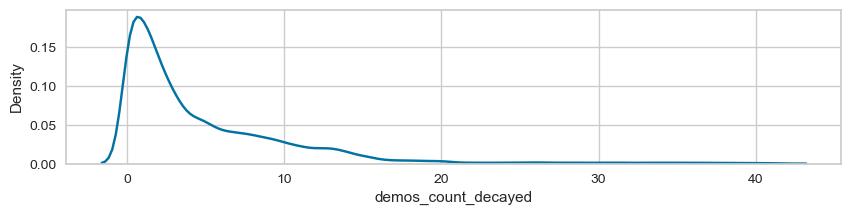

In [119]:
plt.figure(figsize = (10, 2))
sns.kdeplot(parcels['demos_count_decayed'])
plt.show()

In [120]:
parcels['low_exposure'] = np.where(parcels['demos_count_decayed'] < lower_bound, 1, 0)
parcels['high_exposure'] = np.where(parcels['demos_count_decayed'] > upper_bound, 1, 0)

In [121]:
parcels['high_exposure'].value_counts(normalize = True)

high_exposure
0   0.963
1   0.037
Name: proportion, dtype: float64

In [122]:
parcels.groupby('blight')['high_exposure'].mean()

blight
1   0.000
2   0.000
3   0.000
4   0.066
5   0.278
6   0.256
7   0.000
Name: high_exposure, dtype: float64

In [123]:
results = []

prop_pop = parcels['high_exposure'].mean()

for group, gdf in parcels.groupby('blight'):
    n = len(gdf)
    k = int(gdf['high_exposure'].sum())
    prop_group = k / n

    # z-test
    z_t, z_p = proportions_ztest(k, n, prop_pop)

    # binomial test
    bin_p = binomtest(k, n, prop_pop).pvalue

    results.append({
        'group': group,
        'n': n,
        'prop_pop': prop_pop,
        'prop_group': prop_group,
        'z_p': z_p,
        'bin_p': bin_p
    })

results = pd.DataFrame(results)

In [124]:
results

,group,n,prop_pop,prop_group,z_p,bin_p
0,1,47632,0.037,0.000,0.000,0.000
1,2,45724,0.037,0.000,0.000,0.000
2,3,8879,0.037,0.000,0.000,0.000
3,4,27919,0.037,0.066,0.000,0.000
4,5,9697,0.037,0.278,0.000,0.000
5,6,3281,0.037,0.256,0.000,0.000
6,7,899,0.037,0.000,0.000,0.000


In [125]:
parcels.groupby('blight')['demos_count_decayed'].mean()

blight
1    1.275
2    4.447
3    4.154
4    8.303
5   12.188
6   10.708
7    3.405
Name: demos_count_decayed, dtype: float64

In [128]:
parcels.loc[parcels['high_exposure'] == 1]['blight_sqrt'].value_counts(normalize = True)

blight_sqrt
6   0.706
5   0.294
Name: proportion, dtype: float64